In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import warnings
warnings.filterwarnings('ignore')

os.makedirs('reports/figures', exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

rfm = pd.read_parquet('data/processed/rfm_scored.parquet')

print(f'Loaded {len(rfm):,} customers')
print(rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2))

Loaded 4,338 customers
       Recency  Frequency   Monetary
count  4338.00    4338.00    4338.00
mean     92.54       4.27    2048.69
std     100.01       7.70    8985.23
min       1.00       1.00       3.75
25%      18.00       1.00     306.48
50%      51.00       2.00     668.57
75%     142.00       5.00    1660.60
max     374.00     209.00  280206.02


In [3]:
rfm_model = rfm[['Recency', 'Frequency', 'Monetary']].copy()

# Log-transform Monetary to reduce extreme right skew
# log1p = log(x + 1), handles zero values safely
rfm_model['Monetary'] = np.log1p(rfm_model['Monetary'])

# Confirm skew is reduced
print('Skewness before/after log transform:')
print(f'  Monetary raw : {rfm["Monetary"].skew():.2f}')
print(f'  Monetary log : {rfm_model["Monetary"].skew():.2f}')

Skewness before/after log transform:
  Monetary raw : 19.34
  Monetary log : 0.40


In [4]:
scaler = StandardScaler()
X = scaler.fit_transform(rfm_model)

# Confirm scaling worked
scaled_df = pd.DataFrame(X, columns=['Recency', 'Frequency', 'Monetary'])
print('After StandardScaler:')
print(scaled_df.describe().round(3))
# Mean should be ~0, std should be ~1 for all columns

After StandardScaler:
        Recency  Frequency  Monetary
count  4338.000   4338.000  4338.000
mean      0.000      0.000     0.000
std       1.000      1.000     1.000
min      -0.915     -0.425    -3.998
25%      -0.745     -0.425    -0.684
50%      -0.415     -0.295    -0.065
75%       0.495      0.095     0.657
max       2.815     26.598     4.732


  File "C:\Users\HP\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\HP\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\HP\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\HP\anaconda3\Lib\subprocess.py", line 15

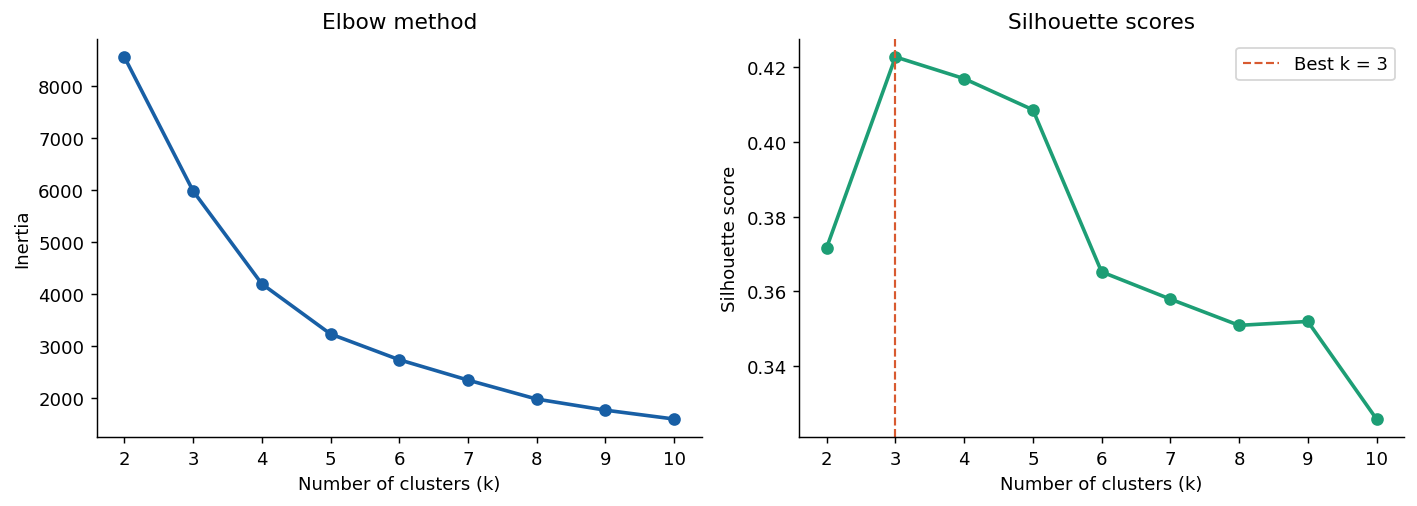

Best silhouette score : 0.423 at k=3

All silhouette scores:
  k=2  0.372
  k=3  0.423
  k=4  0.417
  k=5  0.409
  k=6  0.365
  k=7  0.358
  k=8  0.351
  k=9  0.352
  k=10  0.326


In [5]:
inertias    = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Elbow plot
ax1.plot(K_range, inertias, 'o-', color='#185FA5', linewidth=2, markersize=6)
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow method')
ax1.set_xticks(list(K_range))

# Silhouette plot
ax2.plot(K_range, silhouettes, 'o-', color='#1D9E75', linewidth=2, markersize=6)
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Silhouette score')
ax2.set_title('Silhouette scores')
ax2.set_xticks(list(K_range))

# Mark the best silhouette
best_k = K_range[silhouettes.index(max(silhouettes))]
ax2.axvline(best_k, color='#D85A30', linestyle='--', linewidth=1.2,
            label=f'Best k = {best_k}')
ax2.legend()

plt.tight_layout()
plt.savefig('reports/figures/03_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best silhouette score : {max(silhouettes):.3f} at k={best_k}')
print('\nAll silhouette scores:')
for k, s in zip(K_range, silhouettes):
    print(f'  k={k}  {s:.3f}')

In [6]:
# For RFM data, k=4 typically gives Champions / Loyal / At Risk / Hibernating
K_OPTIMAL = 3

km_final = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
rfm['Cluster'] = km_final.fit_predict(X)

print('Cluster sizes:')
print(rfm['Cluster'].value_counts().sort_index())

Cluster sizes:
Cluster
0    1032
1    2384
2     922
Name: count, dtype: int64


In [7]:
# Profile in original (untransformed) values for readability
cluster_profile = rfm.groupby('Cluster').agg(
    Count        = ('Customer ID', 'count'),
    Avg_Recency  = ('Recency',     'mean'),
    Avg_Frequency= ('Frequency',   'mean'),
    Avg_Monetary = ('Monetary',    'mean'),
    Total_Revenue= ('Monetary',    'sum'),
).round(1)

cluster_profile['Revenue_%'] = (
    cluster_profile['Total_Revenue'] /
    cluster_profile['Total_Revenue'].sum() * 100
).round(1)

print(cluster_profile.sort_values('Avg_Monetary', ascending=False))

# Assign business names based on profile
# Review the table above before setting this mapping
SEGMENT_NAMES = {
    0: 'Champions',
    1: 'Loyal customers',
    2: 'At risk',
    3: 'Hibernating',
}
# Note: your cluster numbers may differ — always check the profile table first
rfm['KMeans_Segment'] = rfm['Cluster'].map(SEGMENT_NAMES)

         Count  Avg_Recency  Avg_Frequency  Avg_Monetary  Total_Revenue  \
Cluster                                                                   
2          922         25.8           11.9        7255.1      6689244.8   
1         2384         50.2            2.5         747.2      1781364.5   
0         1032        250.1            1.5         403.7       416617.6   

         Revenue_%  
Cluster             
2             75.3  
1             20.0  
0              4.7  


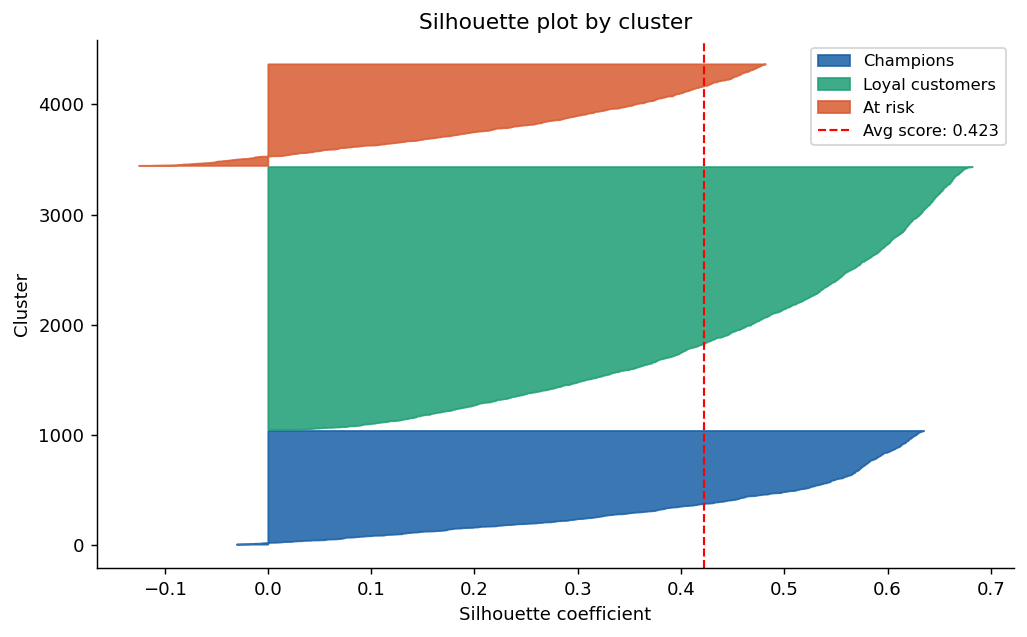

In [8]:
silhouette_vals = silhouette_samples(X, rfm['Cluster'])

fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 10
colors = ['#185FA5', '#1D9E75', '#D85A30', '#888780']

for i in range(K_OPTIMAL):
    cluster_sil = np.sort(silhouette_vals[rfm['Cluster'] == i])
    size = len(cluster_sil)
    y_upper = y_lower + size

    ax.fill_betweenx(np.arange(y_lower, y_upper),
                     0, cluster_sil,
                     alpha=0.85, color=colors[i],
                     label=SEGMENT_NAMES[i])
    y_lower = y_upper + 10

avg_score = silhouette_score(X, rfm['Cluster'])
ax.axvline(avg_score, color='red', linestyle='--', linewidth=1.2,
           label=f'Avg score: {avg_score:.3f}')

ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.set_title('Silhouette plot by cluster')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('reports/figures/03_silhouette_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Cross-tabulation: how do rule-based and K-Means segments overlap?
comparison = pd.crosstab(
    rfm['Segment'],        # rule-based from notebook 02
    rfm['KMeans_Segment'], # data-driven from K-Means
    margins=True
)
print('Rule-based vs K-Means segment overlap:')
print(comparison)

Rule-based vs K-Means segment overlap:
KMeans_Segment       At risk  Champions  Loyal customers   All
Segment                                                       
At risk                   62        122              269   453
Can't lose them            2         33                0    35
Champions                698          0              259   957
Hibernating                5        748              277  1030
Loyal customers          130          0              373   503
Needs attention           10        129              687   826
New customers              1          0               41    42
Potential loyalists       14          0              478   492
All                      922       1032             2384  4338


In [10]:
rfm.to_parquet('data/processed/rfm_clustered.parquet', index=False)

print('Saved → data/processed/rfm_clustered.parquet')
print(f'\nFinal columns: {rfm.columns.tolist()}')
print(f'\nK-Means segment distribution:')
print(rfm['KMeans_Segment'].value_counts())

Saved → data/processed/rfm_clustered.parquet

Final columns: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Segment', 'RFM_Score', 'Segment', 'Cluster', 'KMeans_Segment']

K-Means segment distribution:
KMeans_Segment
Loyal customers    2384
Champions          1032
At risk             922
Name: count, dtype: int64
